In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhoogla/csecicids2018/DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet
/kaggle/input/datasets/dhoogla/csecicids2018/Bruteforce-Wedne

1. GIVE ALL PARQUET FILE PATHS HERE

In [2]:
parquet_paths = [
    "/kaggle/input/datasets/dhoogla/csecicids2018/DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet",
    "/kaggle/input/datasets/dhoogla/csecicids2018/Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet"
]

2. BASIC HELPER FUNCTIONS

In [3]:
def clean_cols(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return df


def get_label_col(df):
    for col in df.columns:
        if col.lower() == "label":
            return col

    for col in df.columns:
        if "label" in col.lower():
            return col

    raise ValueError("Label column not found")


def reduce_memory(df):
    import pandas as pd

    for col in df.columns:
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast="float")

    return df


def clean_one_file(df):
    import numpy as np

    df = clean_cols(df)
    label_col = get_label_col(df)

    # clean label text
    df[label_col] = df[label_col].astype(str).str.strip()

    # replace inf values only in numeric columns
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

    # drop duplicate rows
    df = df.drop_duplicates()

    # reduce memory
    df = reduce_memory(df)

    return df, label_col

3. STRATIFIED SAMPLE FROM ONE FILE

In [4]:
def sample_one_file(df, label_col, sample_frac=0.05, min_per_class=300, max_per_class=15000):
    import pandas as pd

    final_parts = []

    class_counts = df[label_col].value_counts()

    for cls, cnt in class_counts.items():
        temp = df[df[label_col] == cls]

        if cnt <= min_per_class:
            sampled = temp
        else:
            n = int(cnt * sample_frac)
            n = max(n, min_per_class)
            n = min(n, cnt, max_per_class)

            sampled = temp.sample(n=n, random_state=42)

        final_parts.append(sampled)

    df_sample = pd.concat(final_parts, axis=0, ignore_index=True)
    df_sample = df_sample.sample(frac=1.0, random_state=42).reset_index(drop=True)

    return df_sample

4. BUILD MASTER DATASET

In [5]:
def make_master_data(parquet_paths, sample_frac=0.05, min_per_class=300, max_per_class=15000):
    import pandas as pd
    import gc

    all_parts = []

    for i, path in enumerate(parquet_paths):
        print("=" * 70)
        print(f"Reading file {i+1}/{len(parquet_paths)}")
        print(path)

        # load only one parquet file at a time
        df = pd.read_parquet(path)

        # clean current file
        df, label_col = clean_one_file(df)

        print("Original shape :", df.shape)
        print("Unique labels  :", df[label_col].nunique())
        print(df[label_col].value_counts())

        # stratified sample from this file
        df_sample = sample_one_file(
            df=df,
            label_col=label_col,
            sample_frac=sample_frac,
            min_per_class=min_per_class,
            max_per_class=max_per_class
        )

        print("Sampled shape  :", df_sample.shape)
        print("Sampled labels :")
        print(df_sample[label_col].value_counts())

        all_parts.append(df_sample)

        # free RAM
        del df
        gc.collect()

    print("=" * 70)
    print("Combining sampled data from all files...")

    master_df = pd.concat(all_parts, axis=0, ignore_index=True)
    master_df = clean_cols(master_df)

    label_col = get_label_col(master_df)
    master_df[label_col] = master_df[label_col].astype(str).str.strip()

    print("Final master shape :", master_df.shape)
    print("Total unique labels:", master_df[label_col].nunique())
    print(master_df[label_col].value_counts())

    return master_df, label_col

5. EDA FUNCTIONS

In [6]:
def show_basic_info(df, label_col):
    import numpy as np

    print("\n" + "=" * 70)
    print("BASIC INFO")
    print("=" * 70)

    print("Shape:", df.shape)
    print("Total missing values:", df.isnull().sum().sum())
    print("Duplicate rows:", df.duplicated().sum())

    num_df = df.select_dtypes(include=[np.number])
    print("Inf values:", np.isinf(num_df).sum().sum())

    print("\nClass distribution:")
    print(df[label_col].value_counts())


def plot_class_count(df, label_col):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(16, 6))
    counts = df[label_col].value_counts()

    sns.barplot(x=counts.index.astype(str), y=counts.values)
    plt.xticks(rotation=90)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_missing_cols(df, top_n=25):
    import matplotlib.pyplot as plt
    import seaborn as sns

    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False).head(top_n)

    if len(miss) == 0:
        print("\nNo missing values found.")
        return

    plt.figure(figsize=(14, 6))
    sns.barplot(x=miss.index, y=miss.values)
    plt.xticks(rotation=90)
    plt.title(f"Top {top_n} Columns with Missing Values")
    plt.tight_layout()
    plt.show()


def plot_heatmap(df, max_cols=25):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    num_df = df.select_dtypes(include=[np.number]).copy()

    if num_df.shape[1] == 0:
        print("No numeric columns for heatmap")
        return

    # take only first few columns to avoid RAM issue
    num_df = num_df.iloc[:, :max_cols]

    corr = num_df.corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(f"Correlation Heatmap (First {num_df.shape[1]} Numeric Columns)")
    plt.tight_layout()
    plt.show()


def plot_boxplot(df, max_cols=12):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(num_cols) == 0:
        print("No numeric columns for boxplot")
        return

    use_cols = num_cols[:max_cols]

    plt.figure(figsize=(16, 8))
    sns.boxplot(data=df[use_cols])
    plt.xticks(rotation=90)
    plt.title(f"Boxplot of First {len(use_cols)} Numeric Features")
    plt.tight_layout()
    plt.show()


def plot_distribution(df, max_cols=6):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(num_cols) == 0:
        print("No numeric columns for distribution plots")
        return

    use_cols = num_cols[:max_cols]

    for col in use_cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True, bins=50)
        plt.title(f"Distribution of {col}")
        plt.tight_layout()
        plt.show()

6. PREPARE DATA FOR ML

In [7]:
def encode_target(df, label_col):
    from sklearn.preprocessing import LabelEncoder

    le = LabelEncoder()
    df[label_col] = le.fit_transform(df[label_col])

    label_map = {i: cls for i, cls in enumerate(le.classes_)}

    print("\nLabel Mapping:")
    for k, v in label_map.items():
        print(f"{k} -> {v}")

    return df, le, label_map


def make_xy(df, label_col):
    X = df.drop(columns=[label_col]).copy()
    y = df[label_col].copy()

    # keep only numeric columns for ML models
    X = X.select_dtypes(include=["number"])

    print("\nFeature shape:", X.shape)
    print("Target shape :", y.shape)

    return X, y


def drop_high_missing(X, threshold=0.50):
    miss_ratio = X.isnull().mean()
    drop_cols = miss_ratio[miss_ratio > threshold].index.tolist()

    if len(drop_cols) > 0:
        X = X.drop(columns=drop_cols)

    print(f"Dropped {len(drop_cols)} columns with > {threshold*100:.0f}% missing values")

    return X, drop_cols


def drop_high_corr(X, threshold=0.95):
    import numpy as np

    if X.shape[1] <= 1:
        return X, []

    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]

    if len(drop_cols) > 0:
        X = X.drop(columns=drop_cols)

    print(f"Dropped {len(drop_cols)} highly correlated columns")

    return X, drop_cols

7. TRAIN TEST SPLIT

In [8]:
def split_data(X, y, test_size=0.2):
    from sklearn.model_selection import train_test_split

    x_train, x_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    print("\nTrain shape:", x_train.shape, y_train.shape)
    print("Test shape :", x_test.shape, y_test.shape)

    return x_train, x_test, y_train, y_test

8. PREPROCESSING


In [9]:
def do_preprocessing(x_train, x_test, use_scaling=True):
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler

    # fill missing values using train only
    imputer = SimpleImputer(strategy="median")
    x_train = imputer.fit_transform(x_train)
    x_test = imputer.transform(x_test)

    scaler = None

    if use_scaling:
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)
        x_test = scaler.transform(x_test)

    return x_train, x_test, imputer, scaler

In [ ]:
9. PCA (OPTIONAL)

In [12]:
def do_pca(x_train, x_test, use_pca=False, pca_var=0.95):
    from sklearn.decomposition import PCA

    if not use_pca:
        print("\nPCA skipped")
        return x_train, x_test, None

    pca = PCA(n_components=pca_var, random_state=42)

    x_train_pca = pca.fit_transform(x_train)
    x_test_pca = pca.transform(x_test)

    print(f"\nPCA applied: {x_train.shape[1]} -> {x_train_pca.shape[1]}")
    print("Variance kept:", round(pca.explained_variance_ratio_.sum(), 4))

    return x_train_pca, x_test_pca, pca

10. SMOTE (OPTIONAL, ONLY ON TRAIN)

In [13]:
def do_smote(x_train, y_train, use_smote=False):
    import pandas as pd

    if not use_smote:
        print("\nSMOTE skipped")
        return x_train, y_train

    from imblearn.over_sampling import SMOTE

    class_counts = pd.Series(y_train).value_counts()
    min_class = class_counts.min()

    if min_class < 2:
        print("\nSMOTE skipped because some class has less than 2 samples")
        return x_train, y_train

    k = min(5, min_class - 1)
    k = max(1, k)

    smote = SMOTE(random_state=42, k_neighbors=k)
    x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

    print("\nBefore SMOTE:", x_train.shape, len(y_train))
    print("After SMOTE :", x_train_sm.shape, len(y_train_sm))

    return x_train_sm, y_train_sm

In [14]:
def plot_smote_compare(y_train_before, y_train_after):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    before = pd.Series(y_train_before).value_counts().sort_index()
    after = pd.Series(y_train_after).value_counts().sort_index()

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    sns.barplot(x=before.index.astype(str), y=before.values, ax=ax[0])
    ax[0].set_title("Before SMOTE")
    ax[0].tick_params(axis='x', rotation=90)

    sns.barplot(x=after.index.astype(str), y=after.values, ax=ax[1])
    ax[1].set_title("After SMOTE")
    ax[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

11. RANDOM FOREST MODEL

In [15]:
def train_rf(x_train, y_train):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.utils.class_weight import compute_class_weight
    import numpy as np

    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {c: w for c, w in zip(classes, weights)}

    model = RandomForestClassifier(
        n_estimators=150,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight=class_weight_dict
    )

    model.fit(x_train, y_train)

    print("\nRandomForest training done")
    return model

12. XGBOOST MODEL

In [16]:
def train_xgb(x_train, y_train, num_classes):
    try:
        from xgboost import XGBClassifier

        model = XGBClassifier(
            n_estimators=200,
            max_depth=8,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softprob",
            num_class=num_classes,
            random_state=42,
            n_jobs=-1,
            eval_metric="mlogloss"
        )

        model.fit(x_train, y_train)

        print("\nXGBoost training done")
        return model

    except Exception as e:
        print("\nXGBoost not available or failed")
        print("Reason:", e)
        return None

13. EVALUATION

In [17]:
def evaluate_model(model, x_test, y_test, model_name="Model"):
    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay,
        roc_auc_score
    )
    import matplotlib.pyplot as plt

    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(pre, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    plt.figure(figsize=(12, 10))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    result = {
        "model": model_name,
        "accuracy": acc,
        "precision_weighted": pre,
        "recall_weighted": rec,
        "f1_weighted": f1
    }

    # multiclass ROC AUC if possible
    if hasattr(model, "predict_proba"):
        try:
            y_prob = model.predict_proba(x_test)
            auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
            result["roc_auc_ovr_weighted"] = auc
            print("ROC AUC  :", round(auc, 4))
        except Exception as e:
            print("ROC AUC not calculated:", e)

    return result

14. FEATURE IMPORTANCE

In [18]:
def show_feature_importance(model, feature_names, top_n=20, title="Feature Importance"):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    if not hasattr(model, "feature_importances_"):
        print("This model does not support feature importance")
        return

    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    imp_df = imp_df.sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x="importance", y="feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()

15. SAVE THINGS

In [19]:
def save_all(model_dict, imputer, scaler, pca, label_encoder, label_map):
    import joblib

    for name, model in model_dict.items():
        if model is not None:
            joblib.dump(model, f"{name}_model.pkl")

    joblib.dump(imputer, "imputer.pkl")
    joblib.dump(label_encoder, "label_encoder.pkl")
    joblib.dump(label_map, "label_map.pkl")

    if scaler is not None:
        joblib.dump(scaler, "scaler.pkl")

    if pca is not None:
        joblib.dump(pca, "pca.pkl")

    print("\nAll important files saved")

16. MAIN FUNCTION

In [20]:
def run_full_pipeline(
    parquet_paths,
    sample_frac=0.05,
    min_per_class=300,
    max_per_class=15000,
    test_size=0.2,
    use_scaling=True,
    use_pca=False,
    pca_var=0.95,
    use_smote=False
):
    import pandas as pd
    import gc

    # STEP 1: MAKE MASTER DATASET
    master_df, label_col = make_master_data(
        parquet_paths=parquet_paths,
        sample_frac=sample_frac,
        min_per_class=min_per_class,
        max_per_class=max_per_class
    )

    # STEP 2: EDA
    show_basic_info(master_df, label_col)
    plot_class_count(master_df, label_col)
    plot_missing_cols(master_df)
    plot_heatmap(master_df, max_cols=25)
    plot_boxplot(master_df, max_cols=12)
    plot_distribution(master_df, max_cols=6)

    # STEP 3: ENCODE TARGET
    master_df, label_encoder, label_map = encode_target(master_df, label_col)

    # STEP 4: MAKE X AND y
    X, y = make_xy(master_df, label_col)

    # save feature names before transform
    original_feature_names = X.columns.tolist()

    # STEP 5: DROP BAD COLUMNS
    X, drop_miss_cols = drop_high_missing(X, threshold=0.50)
    X, drop_corr_cols = drop_high_corr(X, threshold=0.95)

    final_feature_names = X.columns.tolist()

    print("\nColumns dropped due to missing:", len(drop_miss_cols))
    print("Columns dropped due to corr   :", len(drop_corr_cols))
    print("Final feature count          :", len(final_feature_names))

    # free memory
    del master_df
    gc.collect()

    # STEP 6: TRAIN TEST SPLIT
    x_train, x_test, y_train, y_test = split_data(X, y, test_size=test_size)

    # free memory
    del X, y
    gc.collect()

    # STEP 7: PREPROCESSING
    x_train, x_test, imputer, scaler = do_preprocessing(
        x_train=x_train,
        x_test=x_test,
        use_scaling=use_scaling
    )

    # STEP 8: PCA
    x_train, x_test, pca = do_pca(
        x_train=x_train,
        x_test=x_test,
        use_pca=use_pca,
        pca_var=pca_var
    )

    # STEP 9: SMOTE (ONLY TRAIN)
    y_train_before = y_train.copy()

    x_train_final, y_train_final = do_smote(
        x_train=x_train,
        y_train=y_train,
        use_smote=use_smote
    )

    if use_smote:
        plot_smote_compare(y_train_before, y_train_final)

    # STEP 10: TRAIN RANDOM FOREST
    rf_model = train_rf(x_train_final, y_train_final)

    # STEP 11: TRAIN XGBOOST
    num_classes = len(label_map)
    xgb_model = train_xgb(x_train_final, y_train_final, num_classes=num_classes)

    # STEP 12: EVALUATE MODELS
    results = []

    rf_result = evaluate_model(rf_model, x_test, y_test, model_name="RandomForest")
    results.append(rf_result)

    if xgb_model is not None:
        xgb_result = evaluate_model(xgb_model, x_test, y_test, model_name="XGBoost")
        results.append(xgb_result)

    result_df = pd.DataFrame(results)
    print("\n" + "=" * 70)
    print("MODEL COMPARISON")
    print("=" * 70)
    print(result_df)

    # STEP 13: FEATURE IMPORTANCE
    # only show if PCA is NOT used because feature names stay valid
    if not use_pca:
        show_feature_importance(
            rf_model,
            final_feature_names,
            top_n=20,
            title="RandomForest Feature Importance"
        )

        if xgb_model is not None:
            show_feature_importance(
                xgb_model,
                final_feature_names,
                top_n=20,
                title="XGBoost Feature Importance"
            )

    # STEP 14: SAVE MODELS AND PREPROCESSORS
    model_dict = {
        "random_forest": rf_model,
        "xgboost": xgb_model
    }

    save_all(
        model_dict=model_dict,
        imputer=imputer,
        scaler=scaler,
        pca=pca,
        label_encoder=label_encoder,
        label_map=label_map
    )

    print("\nPipeline completed successfully")

    return {
        "rf_model": rf_model,
        "xgb_model": xgb_model,
        "result_df": result_df,
        "label_map": label_map,
        "imputer": imputer,
        "scaler": scaler,
        "pca": pca,
        "final_feature_names": final_feature_names
    }

Reading file 1/10
/kaggle/input/datasets/dhoogla/csecicids2018/DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet
Original shape : (591873, 78)
Unique labels  : 3
Label
Benign                      446619
DoS attacks-Hulk            145199
DoS attacks-SlowHTTPTest        55
Name: count, dtype: int64
Sampled shape  : (22314, 78)
Sampled labels :
Label
Benign                      15000
DoS attacks-Hulk             7259
DoS attacks-SlowHTTPTest       55
Name: count, dtype: int64
Reading file 2/10
/kaggle/input/datasets/dhoogla/csecicids2018/DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet
Original shape : (794812, 78)
Unique labels  : 3
Label
Benign                   743498
DoS attacks-GoldenEye     41406
DoS attacks-Slowloris      9908
Name: count, dtype: int64
Sampled shape  : (17565, 78)
Sampled labels :
Label
Benign                   15000
DoS attacks-GoldenEye     2070
DoS attacks-Slowloris      495
Name: count, dtype: int64
Reading file 3/10
/kaggle/input/datasets/dho

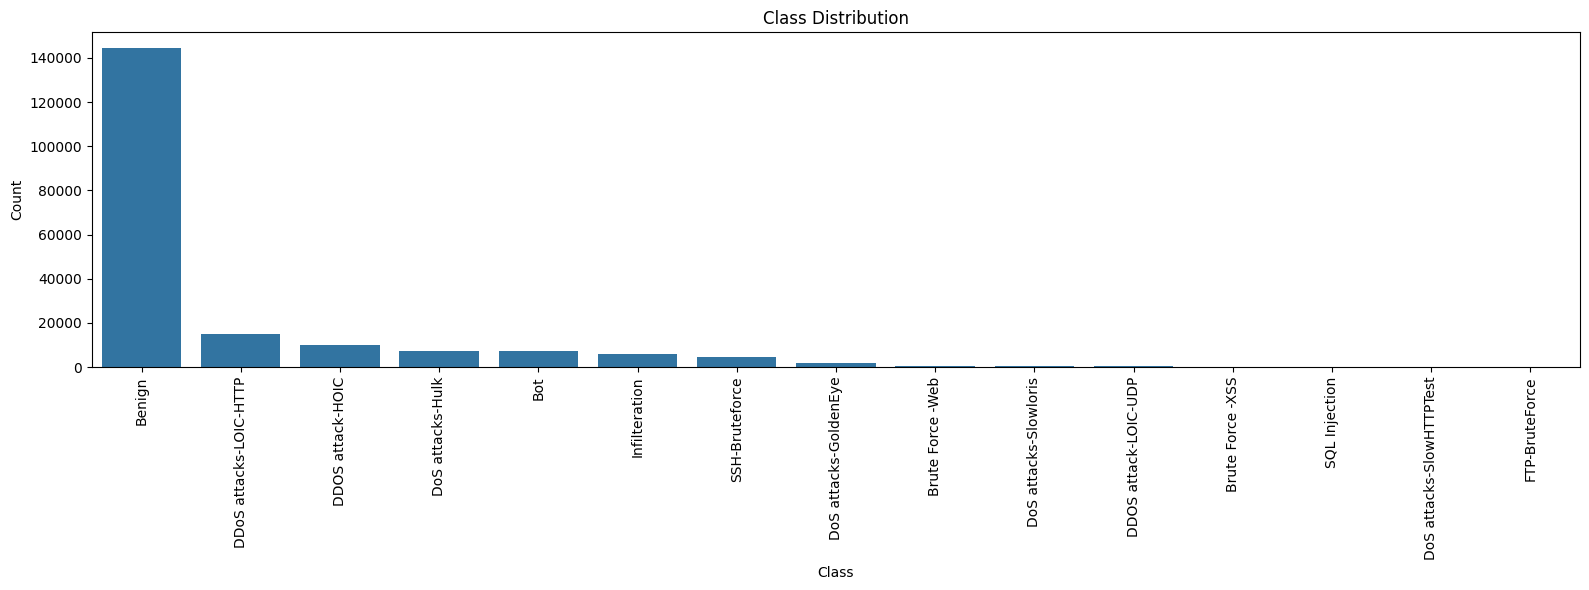


No missing values found.


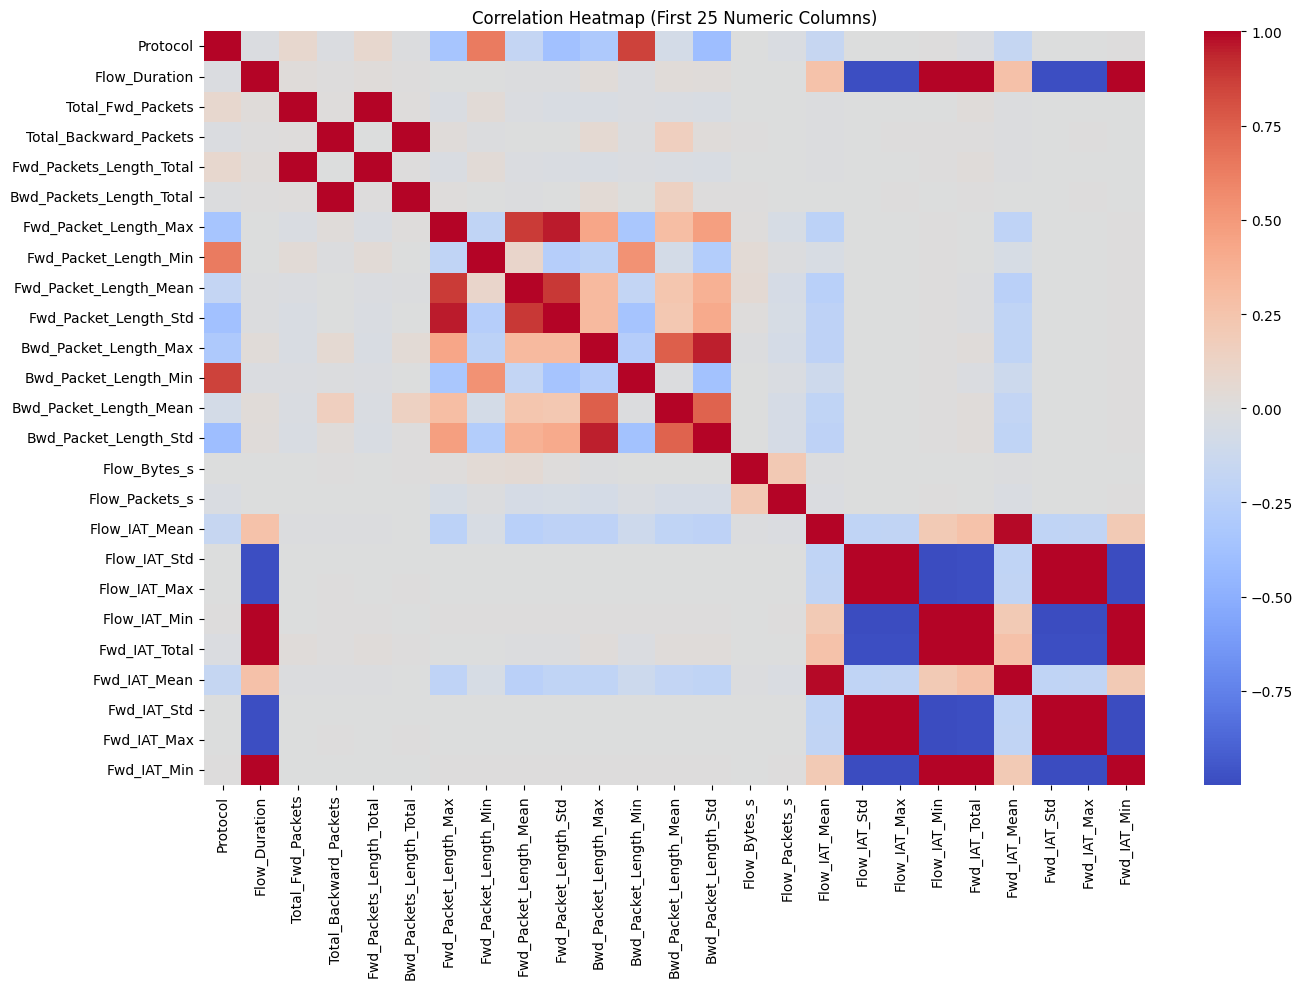

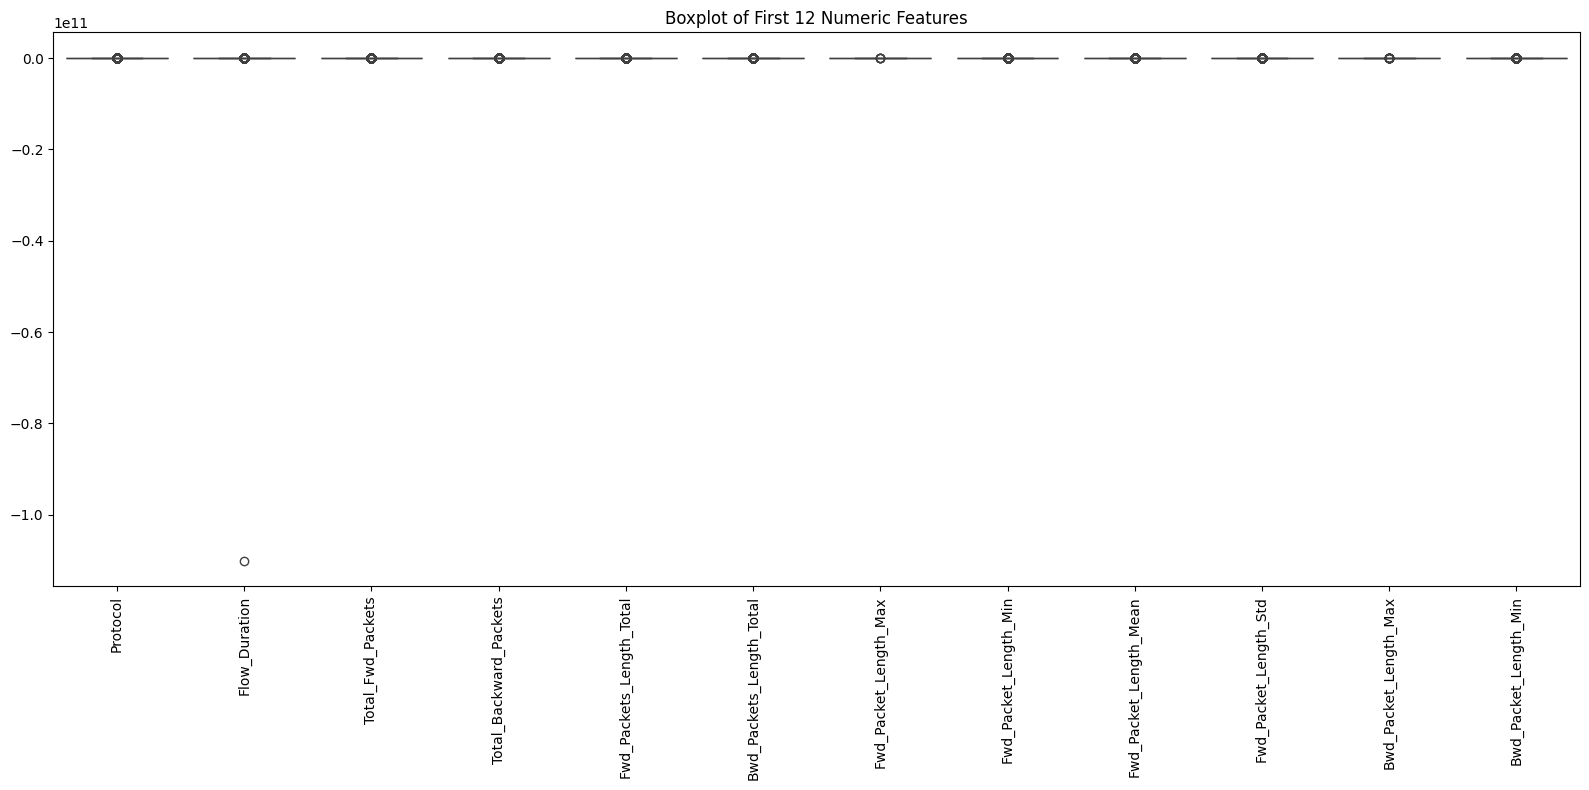

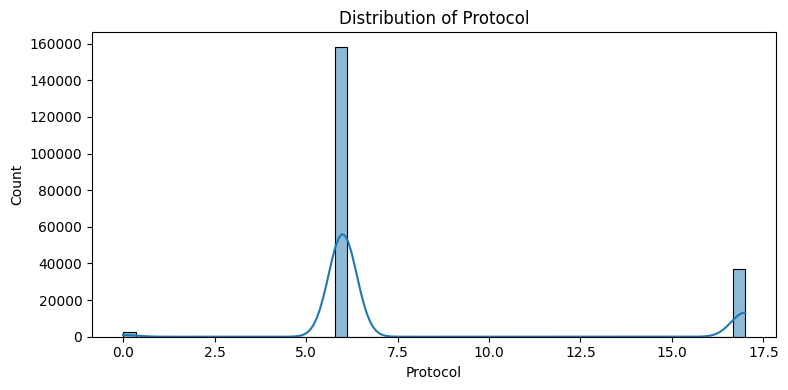

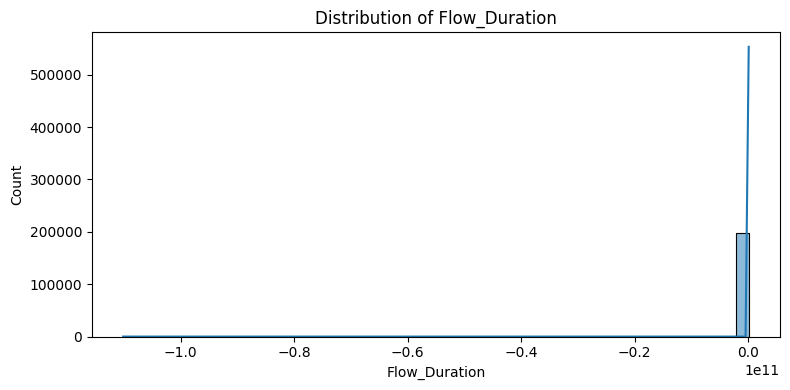

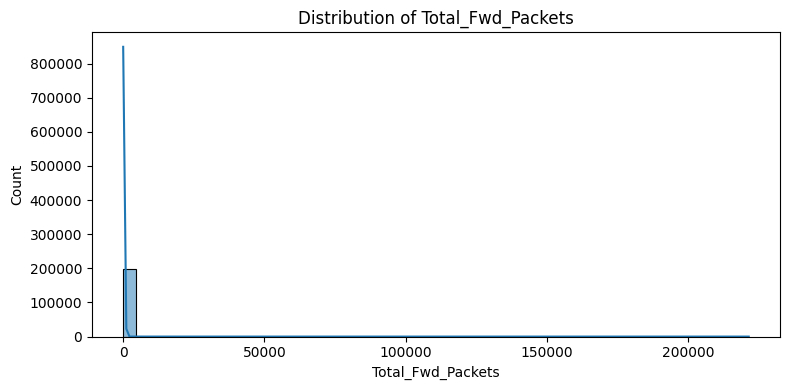

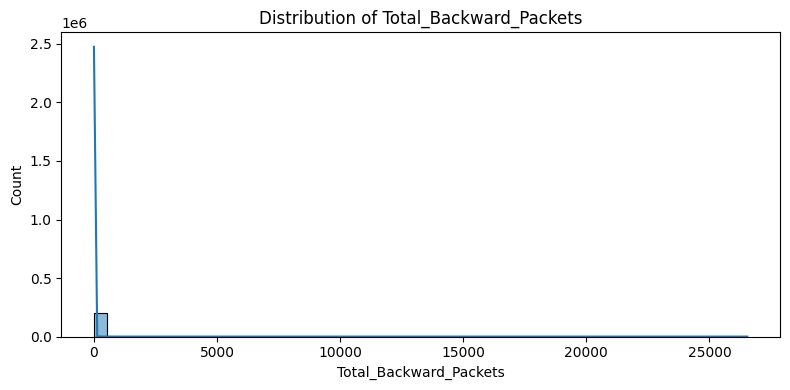

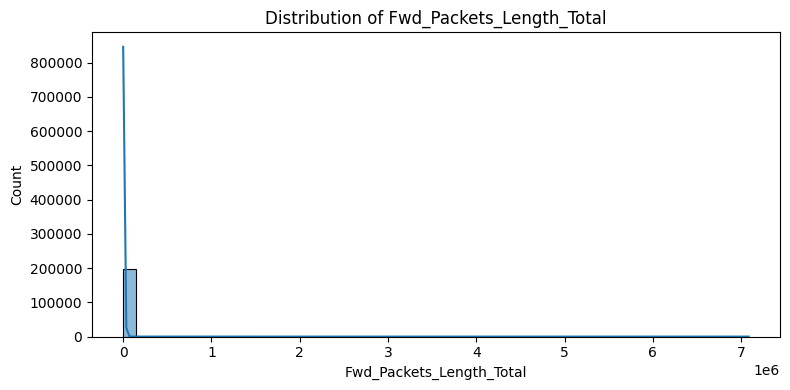

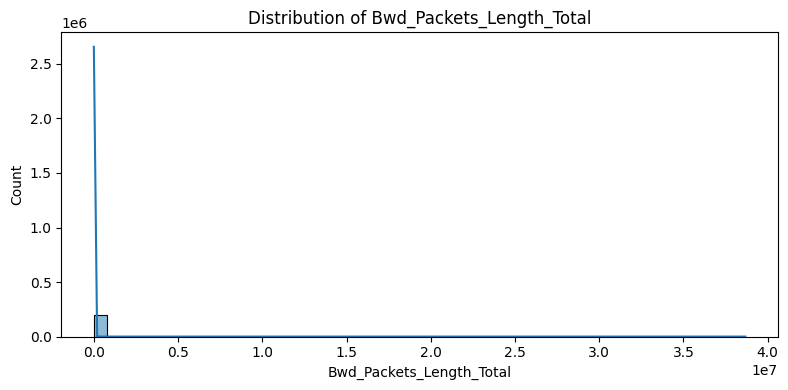


Label Mapping:
0 -> Benign
1 -> Bot
2 -> Brute Force -Web
3 -> Brute Force -XSS
4 -> DDOS attack-HOIC
5 -> DDOS attack-LOIC-UDP
6 -> DDoS attacks-LOIC-HTTP
7 -> DoS attacks-GoldenEye
8 -> DoS attacks-Hulk
9 -> DoS attacks-SlowHTTPTest
10 -> DoS attacks-Slowloris
11 -> FTP-BruteForce
12 -> Infilteration
13 -> SQL Injection
14 -> SSH-Bruteforce

Feature shape: (198224, 77)
Target shape : (198224,)
Dropped 0 columns with > 50% missing values
Dropped 31 highly correlated columns

Columns dropped due to missing: 0
Columns dropped due to corr   : 31
Final feature count          : 46

Train shape: (158579, 46) (158579,)
Test shape : (39645, 46) (39645,)

PCA skipped

Before SMOTE: (158579, 46) 158579
After SMOTE : (1732275, 46) 1732275


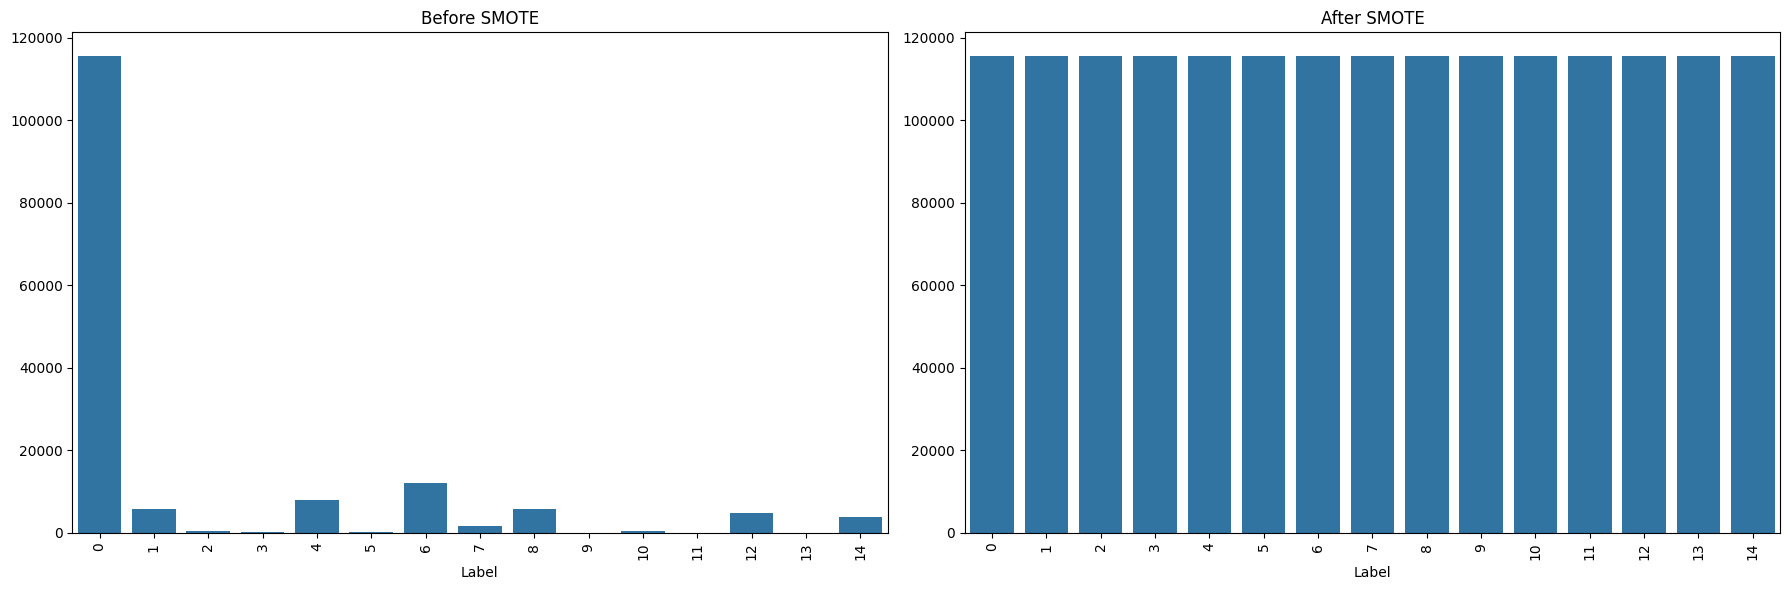


RandomForest training done

XGBoost training done

RandomForest
Accuracy : 0.9152
Precision: 0.9504
Recall   : 0.9152
F1 Score : 0.931

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94     28871
           1       0.99      1.00      0.99      1445
           2       0.73      0.92      0.82       106
           3       0.96      0.93      0.95        46
           4       1.00      1.00      1.00      1989
           5       0.91      0.98      0.94        60
           6       1.00      1.00      1.00      3000
           7       1.00      1.00      1.00       414
           8       1.00      1.00      1.00      1452
           9       0.20      0.18      0.19        11
          10       0.99      1.00      0.99        99
          11       0.18      0.20      0.19        10
          12       0.13      0.32      0.19      1185
          13       0.47      0.88      0.61        17
          14       1.00      

<Figure size 1200x1000 with 0 Axes>

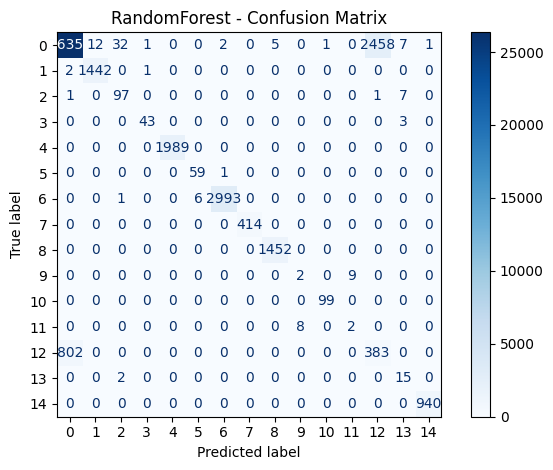

ROC AUC  : 0.9805

XGBoost
Accuracy : 0.8584
Precision: 0.9545
Recall   : 0.8584
F1 Score : 0.8974

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     28871
           1       0.99      1.00      0.99      1445
           2       0.41      0.91      0.56       106
           3       0.91      0.93      0.92        46
           4       1.00      1.00      1.00      1989
           5       0.90      0.93      0.92        60
           6       1.00      1.00      1.00      3000
           7       1.00      1.00      1.00       414
           8       1.00      1.00      1.00      1452
           9       0.33      0.36      0.35        11
          10       0.99      1.00      0.99        99
          11       0.22      0.20      0.21        10
          12       0.12      0.55      0.19      1185
          13       0.48      0.88      0.62        17
          14       1.00      1.00      1.00       940

    accurac

<Figure size 1200x1000 with 0 Axes>

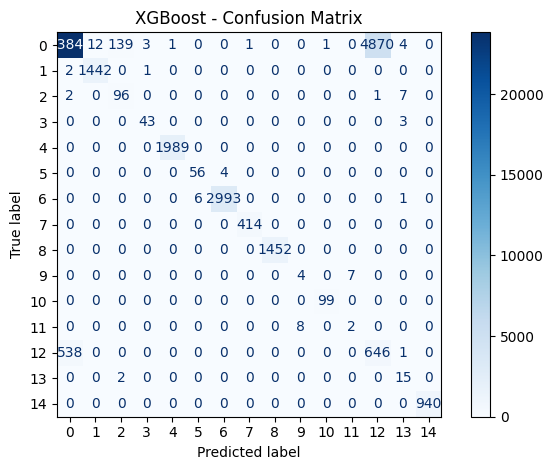

ROC AUC  : 0.9812

MODEL COMPARISON
          model  accuracy  precision_weighted  recall_weighted  f1_weighted  \
0  RandomForest  0.915172            0.950442         0.915172     0.930950   
1       XGBoost  0.858393            0.954506         0.858393     0.897366   

   roc_auc_ovr_weighted  
0              0.980493  
1              0.981171  


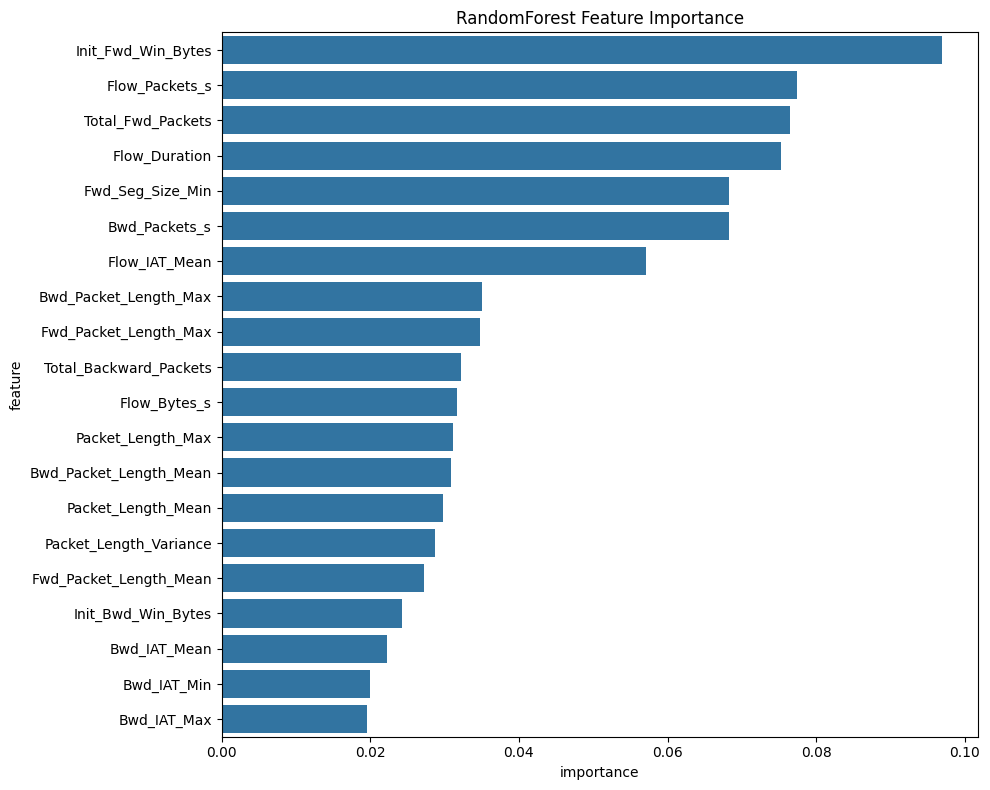

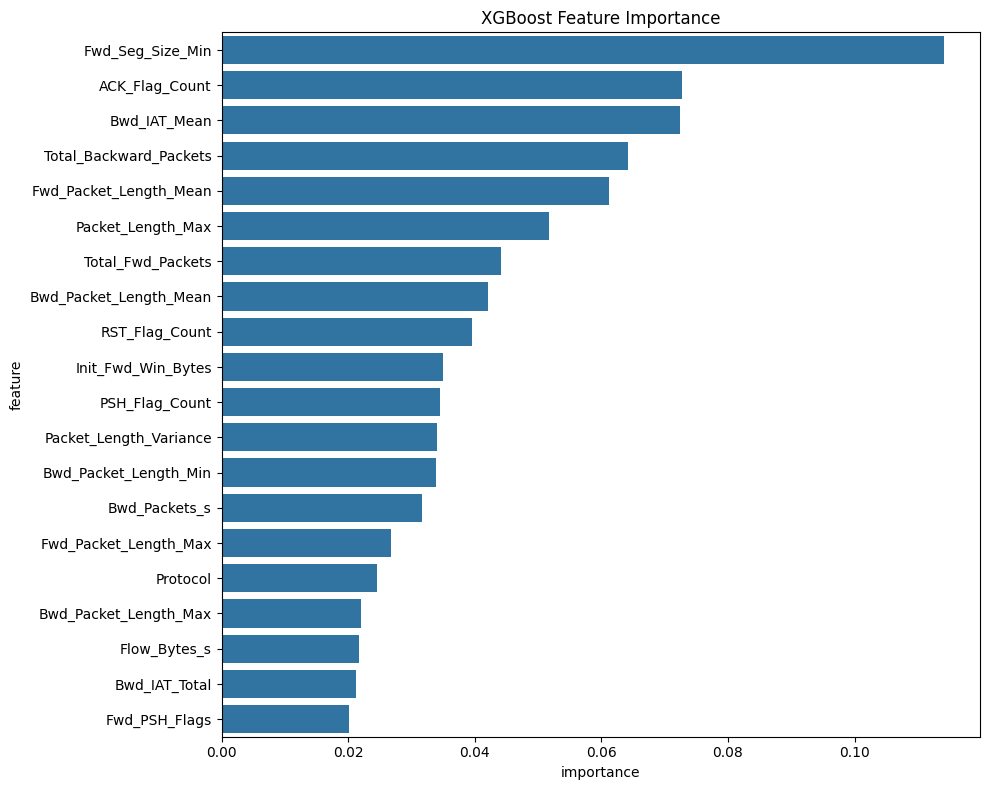


All important files saved

Pipeline completed successfully


In [21]:
results = run_full_pipeline(
    parquet_paths=parquet_paths,
    sample_frac=0.05,      # start with 5%
    min_per_class=300,     # keep rare classes
    max_per_class=15000,   # control majority class
    test_size=0.2,
    use_scaling=True,
    use_pca=False,         # keep False for RF/XGB
    pca_var=0.95,
    use_smote=True        # keep False first due to RAM issue
)